# <center>五 LangGrpah 单代理架构应用(下)

&emsp;&emsp;前面我们介绍了 `Router Agent` 和 `Tool Calling Agent`，我们通过两个实际的案例证明了**随着任务需求的复杂性增加，代理架构中对中间流程的控制自由度也必须相应提高**。之所以要从 `Router Agent` 调整到 `Tool Calling Agent` 架构的原因在于，**当路由分支中的节点涉及多个工具时，需要`Agent`可以根据用户的实际输入灵活选择工具，这一需求是 `Router Agent` 无法满足的。然而，`Tool Calling Agent` 的局限性又在于：虽然它可以自主选择工具，但在其架构中，每次仅能执行一次函数调用（无论是单个外部函数还是多个外部函数）**。因此，当任务需要依次执行 A 工具、B 工具和 C 工具时，它无法支持这种自主控制的过程。因此，面对这种更复杂的需求，就需要引入了 `Full Autonomous`（自治循环代理）架构，即如下图所示：

<div align=center><img src="../pic/lesson05/1.png" width=70%></div>

&emsp;&emsp; `Full Autonmonous` 以两种主要的方式去扩展了`Agent`对工作流的控制，分别是：

- 多步骤决策： `Agent`可以控制一系列决策，而不仅仅是一个决策。
- 工具访问： `Agent`可以选择并使用多种工具来完成任务。

&emsp;&emsp;**满足上述两个条件，典型且通用的代理架构，就是基于`ReAct`思想而形成的代理模式**。在《ReAct 智能应用架构深度剖析》课程中，我们重点讲解了`ReAct`的核心理念，并手动实现了基于该思想构建的自治循环代理流程。整体来看，其核心还是在于**为大模型配备足够丰富的外部工具，使用合适的提示词，引导大模型在接收到用户输入后，进入自主思考和循环执行的状态，以实现最终目标。** 当然，这是我们从非技术角度通俗的解释和理解自治循环代理的这个过程。

&emsp;&emsp;接下来我们花10分钟的时间回忆一些ReAct的原理

<div align=center><img src="../pic/lesson05/4.png" width=70%></div>

<div align=center><img src="../pic/lesson05/5.png" width=70%></div>

<div align=center><img src="../pic/lesson05/6.png" width=70%></div>

# 1. LangGraph中ReAct的构建原理

&emsp;&emsp;在 `LangGraph` 开发框架中有一些预构建的组件。上节课介绍的 `ToolNode` 是其中一个，它用于处理外部函数调用，其内部结合了 `LangGraph` 底层的图结构，能够接收 `JSON Schema` 形式的数据，执行工具函数并返回结果。除此之外，`LangGraph`的预构建组件中还包含了 `ReAct` 代理架构，该架构与我们在《ReAct 智能应用架构深度剖析》中手动实现的思路和流程基本一致。不同之处在于，**在 `LangGraph` 框架中，`ReAct` 组件被改造成适配图结构的循环代理，其具体过程是：大模型可以在一个 `while` 循环中被重复调用。每一步，代理来自主决定调用哪些工具及其输入，然后执行这些工具，并将输出作为观察结果反馈给大模型。当代理判断不再需要调用更多工具时，`while` 循环便会终止，输出最终的结果。**

&emsp;&emsp;**因此，我们需要理解的关键概念是：`LangGraph`预构建的`ReAct`组件，其实就是通过接入大模型，搭配着`Tool Calling Agent`，再结合`Router Agent` 共同构建起来的图，这个图以自治循环代理的架构形式提供服务。**其图结构如下图所示：

<div align=center><img src="../pic/lesson05/2.png" width=60%></div>

&emsp;&emsp;如上图所示的代理架构在 `LangGraph` 中的实现机制类似于 `LangChain` 中的 `ReAct Agent`，毕竟 `LangGraph` 的底层语言是 `LangChain` 的 `LCEL` 表达式语言。因此，该 `ReAct Agent` 架构是从 `LangChain` 已实现的 `ReAct Agent` 迁移而来，不同的是在`LangGraph`框架中适配的是图结构，而非`AgentExecuter`。其本质依然基于一种规划（Planning）的思想：

> LangChain Agents Type： https://python.langchain.com/v0.1/docs/modules/agents/agent_types/
>
> Agent Planning：https://smith.langchain.com/hub/hwchase17/react?organizationId=33612d73-91c5-5140-b8a0-f3155ff5dc45

```json
Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer

Thought: you should always think about what to do

Action: the action to take, should be one of [{tool_names}]

Action Input: the input to the action

Observation: the result of the action

... (this Thought/Action/Action Input/Observation can repeat N times)

Thought: I now know the final answer

Final Answer: the final answer to the original input question

Begin!

Question: {input}

Thought:{agent_scratchpad}
```

&emsp;&emsp;这种代理实现的机制表明了，在`LangGraph`中实现的预构建`ReAct`代理结构，它支持：

- **Tool calling ：允许大模型根据需要选择和使用各种工具。**
- **Memory：使代理能够保留和使用先前步骤中的信息。**
- **Planning ：授权大模型制定并遵循多步骤计划以实现目标。**


&emsp;&emsp;而其在图结构中的具体构建的工作流如下图所示：

<div align=center><img src="../pic/lesson05/3.png" width=60%></div>

&emsp;&emsp;如图所示，`Agent`节点使用消息列表的形式来调用大语言模型，`Messages Modifier`指的是在传递到大模型之前，修饰用户的原始输入内容，可以是`SystemMessage`（作为背景信息添加的消息列表的开头）、`Runnable`（可运行）等不同状态，如果生成的 `AIMessage` 包含`tool_calls`，则该图将调用 `tools` 。 `tools` 节点执行工具（每个 `tool_call` 1 个工具）并且将响应作为`ToolMessage`对象添加到消息列表。然后`Agent`节点再次调用大语言模型。重复该过程，直到响应中不再存在`tool_calls` ，最终由`Agent`节点将完整的消息列表作为包含键 `messages`的字典返回。

&emsp;&emsp;那么如何实现上述这个非常复杂的过程呢？非常简单，既然我们一直提到的是预构建组件，则说明整个过程已经由`LangGraph`内部封装好了，其提供给开发者使用的接口就是：`create_react_agent`方法。

> LangGraph create_react_agent：[点击查看源码参数介绍](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=create+react+agent#langgraph.prebuilt.chat_agent_executor.create_react_agent)

# 2. 案例实操：构建复杂工具应用的ReAct自治代理

&emsp;&emsp;在这个案例中，我们将通过一个多工具场景需求来测试 `LangGraph` 中 `ReAct` 代理的构建方法和效果。我们设计了几个工具，以实现实时数据的查询和管理。首先，用户可以通过一个工具根据城市名称实时获取当前天气信息。接着，如果用户希望将查询到的天气数据保存到本地数据库中，可以使用另一个工具完成数据的插入操作。此外，我们还提供了一个工具，允许用户基于本地数据库中的天气数据进行提问数据进行提问。通过这些工具的组合，我们能够快速验证如何在复杂的应用场景中有效地整合不同功能，并实际的感知`LangGraph`框架下`ReAct`代理模式带来的开发便捷性和可扩展性。

&emsp;&emsp;首先，我们接入实时天气数据查询的在线API，代码定义如下：

> WeatherAPI 的注册与使用，注册地址：https://www.weatherapi.com/

In [11]:
import requests
import json

WEATHERAPI_KEY = "02d81e92a8664fb7a8a81039260908"
WEATHERAPI_CURRENT_URL = "https://api.weatherapi.com/v1/current.json"


def _condition_to_main(code: int) -> str:
    """Map WeatherAPI condition code to OpenWeather-style main category."""
    if code == 1000:
        return "Clear"
    if code in (1003, 1006, 1009):
        return "Clouds"
    if code in (1030, 1135, 1147):
        return "Mist"
    if code in (1087, 1273, 1276, 1279, 1282):
        return "Thunderstorm"
    if code in (1066, 1114, 1117, 1210, 1213, 1216, 1219, 1222, 1225, 1237, 1255, 1258):
        return "Snow"
    if code >= 1063:
        return "Rain"
    return "Unknown"


def _fetch_weatherapi_current(city_name: str) -> dict:
    """Fetch current weather from WeatherAPI.com."""
    response = requests.get(
        WEATHERAPI_CURRENT_URL,
        params={"key": WEATHERAPI_KEY, "q": city_name, "lang": "zh"},
        timeout=30,
    )
    response.raise_for_status()
    return response.json()


def _normalize_weather_payload(payload: dict, query_name: str) -> dict:
    """Normalize WeatherAPI.com response to the legacy OpenWeather-style shape."""
    location = payload["location"]
    current = payload["current"]
    condition = current["condition"]
    lat = location["lat"]
    lon = location["lon"]
    temp = current["temp_c"]
    city_id = int(abs(round(lat * 100)) * 1_000_000 + abs(round(lon * 100)))
    vis_km = current.get("vis_km")
    visibility = int(vis_km * 1000) if vis_km is not None else None

    return {
        "coord": {"lon": lon, "lat": lat},
        "weather": [{
            "id": condition["code"],
            "main": _condition_to_main(condition["code"]),
            "description": condition["text"],
            "icon": condition.get("icon", ""),
        }],
        "main": {
            "temp": temp,
            "feels_like": current.get("feelslike_c", temp),
            "temp_min": temp,
            "temp_max": temp,
            "pressure": current.get("pressure_mb"),
            "humidity": current.get("humidity"),
        },
        "visibility": visibility,
        "wind": {
            "speed": round(current.get("wind_kph", 0) / 3.6, 2),
            "deg": current.get("wind_degree"),
        },
        "clouds": {"all": current.get("cloud", 0)},
        "dt": current.get("last_updated_epoch"),
        "timezone": None,
        "id": city_id,
        "name": location.get("name", query_name),
        "cod": 200,
    }


def _get_weather_data(city_name: str) -> dict:
    payload = _fetch_weatherapi_current(city_name)
    return _normalize_weather_payload(payload, city_name)


def get_weather(loc):
    """
    Function to query current weather.
    :param loc: Required parameter, of type string, representing the specific city name for the weather query. \
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing, \
    the loc parameter should be input as 'Beijing'.
    :return: Current weather from WeatherAPI.com, normalized to a JSON string.
    """
    data = _get_weather_data(loc)
    return json.dumps(data, ensure_ascii=False)

&emsp;&emsp;测试一下`get_weather`函数的有效性，正常情况下可以得到输入城市名的实时天气信息。测试代码如下所示：

In [12]:
get_weather('beijing')

'{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1000, "main": "Clear", "description": "晴天", "icon": "//cdn.weatherapi.com/weather/64x64/day/113.png"}], "main": {"temp": 31.2, "feels_like": 30.8, "temp_min": 31.2, "temp_max": 31.2, "pressure": 1007.0, "humidity": 39}, "visibility": 10000, "wind": {"speed": 3.31, "deg": 176}, "clouds": {"all": 10}, "dt": 1786262400, "timezone": null, "id": 3993011639, "name": "Beijing", "cod": 200}'

&emsp;&emsp;从返回的结果是`Json`数据类型，包含了非常丰富的实时天气数据，如天气条件、温度、湿度、风速、天气描述等信息，这里我们选择一些重要的数据参数进行存储操作（存储至Mysql数据库中）。提取的参数如下：

| 字段名称      | 描述                       |
|---------------|----------------------------|
| city_id       | 城市唯一标识符（对应 JSON 中的 `id`） |
| city_name     | 城市名称（对应 JSON 中的 `name`） |
| lon           | 经度（对应 `coord.lon`）   |
| lat           | 纬度（对应 `coord.lat`）   |
| condition_id  | 天气状况代码（对应 `weather[0].id`） |
| main_weather  | 主要天气状况（对应 `weather[0].main`） |
| description   | 天气详细描述（对应 `weather[0].description`） |
| icon          | 天气图标 URL（对应 `weather[0].icon`） |
| temperature   | 当前温度（对应 `main.temp`） |
| feels_like    | 体感温度（对应 `main.feels_like`） |
| temp_min      | 最低温度（对应 `main.temp_min`） |
| temp_max      | 最高温度（对应 `main.temp_max`） |
| pressure      | 气压（对应 `main.pressure`） |
| humidity      | 湿度（对应 `main.humidity`） |
| visibility    | 能见度，单位米（对应 `visibility`） |
| wind_speed    | 风速，单位 m/s（对应 `wind.speed`） |
| wind_deg      | 风向角度（对应 `wind.deg`） |
| clouds        | 云量百分比（对应 `clouds.all`） |
| observed_at   | 观测时间戳（对应 `dt`） |


&emsp;&emsp;接下来，设计一个用于存储实时天气信息的表。这里我们定义一个新的模型 `Weather`，并包括上述所提取出来的的字段。连接 `Mysql`数据库及创建表的代码如下所示：

In [13]:
from sqlalchemy import create_engine, Column, Integer, String, Float, BigInteger, text
from sqlalchemy.orm import sessionmaker, declarative_base

# 创建基类
Base = declarative_base()

# 定义 Weather 模型（字段与 WeatherAPI 归一化后的 JSON 结构对应）
class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(BigInteger, primary_key=True)       # id
    city_name = Column(String(50))                     # name
    lon = Column(Float)                                  # coord.lon
    lat = Column(Float)                                  # coord.lat
    condition_id = Column(Integer)                       # weather[0].id
    main_weather = Column(String(50))                    # weather[0].main
    description = Column(String(100))                    # weather[0].description
    icon = Column(String(200))                           # weather[0].icon
    temperature = Column(Float)                          # main.temp
    feels_like = Column(Float)                           # main.feels_like
    temp_min = Column(Float)                             # main.temp_min
    temp_max = Column(Float)                             # main.temp_max
    pressure = Column(Float)                             # main.pressure
    humidity = Column(Integer)                           # main.humidity
    visibility = Column(Integer)                         # visibility
    wind_speed = Column(Float)                           # wind.speed
    wind_deg = Column(Integer)                           # wind.deg
    clouds = Column(Integer)                             # clouds.all
    observed_at = Column(BigInteger)                     # dt


# 数据库连接配置（macOS 本地 MySQL）
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_DATABASE = "langgraph"

# 先创建数据库（如果不存在）
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/?charset=utf8mb4"
)
with server_engine.connect() as conn:
    conn.execute(text(
        f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE} "
        "CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
    ))
    conn.commit()

DATABASE_URI = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/"
    f"{MYSQL_DATABASE}?charset=utf8mb4"
)
engine = create_engine(DATABASE_URI)

# 表结构变更时重建表（开发环境）
Weather.__table__.drop(engine, checkfirst=True)
Base.metadata.create_all(engine)

# 创建会话
Session = sessionmaker(bind=engine)

&emsp;&emsp;接下来，使用`LangChain`的`tool` 装饰器将普通的函数注册为`LangGraph`中支持的工具服务，根据需求的设计，我们要依次创建三个外部函数，分别是：
1. `get_weather`工具：用于根据城市名称实时查询该城市的当前天气数据。
2. `insert_weather_to_db`工具：如果用户想要把查询到的天气数据插入到数据库的表中，则使用此函数完成数据库的插入操作。
3. `query_weather_from_db`工具：如果用户想基于本地数据库的天气数据直接进行提问，则使用此函数完成数据库的查询操作。

&emsp;&emsp;如上节课实践的流程一样，我们依然使用`pydantic`来做工具的参数校验和结构化输出。三个工具函数的定义代码依次如下所示：

In [14]:
from langchain_core.tools import tool
from typing import Union, Optional
from pydantic import BaseModel, Field
import requests


def _weather_row_to_payload(weather_data: Weather) -> dict:
    """Convert a Weather ORM row to the same JSON shape returned by get_weather."""
    return {
        "coord": {"lon": weather_data.lon, "lat": weather_data.lat},
        "weather": [{
            "id": weather_data.condition_id,
            "main": weather_data.main_weather,
            "description": weather_data.description,
            "icon": weather_data.icon,
        }],
        "main": {
            "temp": weather_data.temperature,
            "feels_like": weather_data.feels_like,
            "temp_min": weather_data.temp_min,
            "temp_max": weather_data.temp_max,
            "pressure": weather_data.pressure,
            "humidity": weather_data.humidity,
        },
        "visibility": weather_data.visibility,
        "wind": {
            "speed": weather_data.wind_speed,
            "deg": weather_data.wind_deg,
        },
        "clouds": {"all": weather_data.clouds},
        "dt": weather_data.observed_at,
        "timezone": None,
        "id": weather_data.city_id,
        "name": weather_data.city_name,
        "cod": 200,
    }


## 第一个工具

class WeatherLoc(BaseModel):
    location: str = Field(description="The location name of the city")


class WeatherInfo(BaseModel):
    """Extracted weather information for a specific city."""
    city_id: int = Field(..., description="City ID from the `id` field")
    city_name: str = Field(..., description="City name from the `name` field")
    lon: float = Field(..., description="Longitude from `coord.lon`")
    lat: float = Field(..., description="Latitude from `coord.lat`")
    condition_id: int = Field(..., description="Weather condition code from `weather[0].id`")
    main_weather: str = Field(..., description="Main weather condition from `weather[0].main`")
    description: str = Field(..., description="Weather description from `weather[0].description`")
    icon: str = Field(..., description="Weather icon URL from `weather[0].icon`")
    temperature: float = Field(..., description="Current temperature from `main.temp`")
    feels_like: float = Field(..., description="Feels-like temperature from `main.feels_like`")
    temp_min: float = Field(..., description="Minimum temperature from `main.temp_min`")
    temp_max: float = Field(..., description="Maximum temperature from `main.temp_max`")
    pressure: float = Field(..., description="Air pressure from `main.pressure`")
    humidity: int = Field(..., description="Humidity from `main.humidity`")
    visibility: int = Field(..., description="Visibility in meters from `visibility`")
    wind_speed: float = Field(..., description="Wind speed in m/s from `wind.speed`")
    wind_deg: int = Field(..., description="Wind direction in degrees from `wind.deg`")
    clouds: int = Field(..., description="Cloud coverage percentage from `clouds.all`")
    observed_at: int = Field(..., description="Observation timestamp from `dt`")

@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    Function to query current weather.
    :param loc: Required parameter, of type string, representing the specific city name for the weather query. \
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing, \
    the loc parameter should be input as 'Beijing'.
    :return: Current weather from WeatherAPI.com, normalized to a JSON string.
    """
    data = _get_weather_data(location)
    return json.dumps(data, ensure_ascii=False)
    

## 第二个工具

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(
    city_id,
    city_name,
    lon,
    lat,
    condition_id,
    main_weather,
    description,
    icon,
    temperature,
    feels_like,
    temp_min,
    temp_max,
    pressure,
    humidity,
    visibility,
    wind_speed,
    wind_deg,
    clouds,
    observed_at,
):
    """Insert weather information into the database."""
    session = Session()  # 确保为每次操作创建新的会话
    try:
        weather = Weather(
            city_id=city_id,
            city_name=city_name,
            lon=lon,
            lat=lat,
            condition_id=condition_id,
            main_weather=main_weather,
            description=description,
            icon=icon,
            temperature=temperature,
            feels_like=feels_like,
            temp_min=temp_min,
            temp_max=temp_max,
            pressure=pressure,
            humidity=humidity,
            visibility=visibility,
            wind_speed=wind_speed,
            wind_deg=wind_deg,
            clouds=clouds,
            observed_at=observed_at,
        )
        session.merge(weather)
        session.commit()
        return {"messages": [f"天气数据已成功存储至Mysql数据库。"]}
    except Exception as e:
        session.rollback()  # 出错时回滚
        return {"messages": [f"数据存储失败，错误原因：{e}"]}
    finally:
        session.close()  # 关闭会话

## 第三个工具

class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name."""
    city_name: str = Field(..., description="The name of the city to query weather information")
    
@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name: str):
    """Query weather information from the database by city name."""
    session = Session()
    try:
        weather_data = session.query(Weather).filter(Weather.city_name == city_name).first()
        if weather_data:
            return _weather_row_to_payload(weather_data)
        else:
            return {"messages": [f"未找到城市 '{city_name}' 的天气信息。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因：{e}"]}
    finally:
        session.close()  # 关闭会话

&emsp;&emsp;然后，定义实时联网检索外部工具，通过该函数获取最新的网络数据信息。

In [15]:
## 第四个工具

class SearchQuery(BaseModel):
    query: str = Field(description="Questions for networking queries")


@tool(args_schema = SearchQuery)
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({
      "q": query,
      "num": 1,
    })
    headers = {
      'X-API-KEY': '09b88d55900377e05b0aa283b7cefa97ca73a439',
      'Content-Type': 'application/json'
    }
    
    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)  # 将返回的JSON字符串转换为字典
    if 'organic' in data:
        return json.dumps(data['organic'],  ensure_ascii=False)  # 返回'organic'部分的JSON字符串
    else:
        return json.dumps({"error": "No organic results found"},  ensure_ascii=False)  # 如果没有'organic'键，返回错误信息

&emsp;&emsp;然后把所有定义的工具存储在一个列表中，如下代码所示：

In [16]:
tools = [fetch_real_time_info, get_weather, insert_weather_to_db, query_weather_from_db]

In [17]:
tools

[StructuredTool(name='fetch_real_time_info', description='Get real-time Internet information', args_schema=<class '__main__.SearchQuery'>, func=<function fetch_real_time_info at 0x130f52700>),
 StructuredTool(name='get_weather', description="Function to query current weather.\n:param loc: Required parameter, of type string, representing the specific city name for the weather query.     Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,     the loc parameter should be input as 'Beijing'.\n:return: Current weather from WeatherAPI.com, normalized to a JSON string.", args_schema=<class '__main__.WeatherLoc'>, func=<function get_weather at 0x130f52520>),
 StructuredTool(name='insert_weather_to_db', description='Insert weather information into the database.', args_schema=<class '__main__.WeatherInfo'>, func=<function insert_weather_to_db at 0x130f52480>),
 StructuredTool(name='query_weather_from_db', description='

&emsp;&emsp;准备好工具后，接下来定义用于构建`AI Agent`的大模型实例，这里我们使用 DeepSeek 的 `deepseek-chat` 模型。代码如下：

In [18]:
from langchain_openai import ChatOpenAI

# DeepSeek API 配置
key = "sk-c121e4a7110945ff8f23db283ecdbb2c"
base_url = "https://api.deepseek.com/v1"

In [19]:
llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

&emsp;&emsp;当有了工具列表和模型后，就可以通过`create_react_agent`这个`LangGraph`框架中预构建的方法来创建自治循环代理（ReAct）的工作流，其必要的参数如下：

- model： 支持工具调用的LangChain聊天模型。
- tools： 工具列表、ToolExecutor 或 ToolNode 实例。
- state_schema：图的状态模式。必须有`messages`和`is_last_step`键。默认为定义这两个键的`Agent State`。

&emsp;&emsp;上述三点我们均在前面的课程中详细且作为重点介绍过，大家应该是比较容易理解的。所以，创建`ReAct`代理的代码就如下所示：

In [20]:
from langgraph.prebuilt import create_react_agent

graph = create_react_agent(llm, tools=tools)

/var/folders/hm/p5x9q0gj1tq37tdyp_pjmqgh0000gn/T/ipykernel_98058/608451744.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(llm, tools=tools)


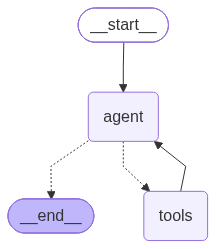

In [21]:
graph

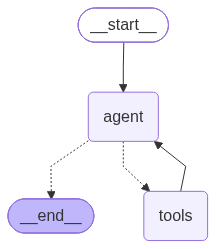

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

&emsp;&emsp;我们可以逐步的分析和解释一下这一行代码中涉及的图构建过程：

- **Step 1. 定义图状态模式**

&emsp;&emsp;`LangGraph`中的主要图类型是`StateGraph`。每个节点通过`State`中的参数获取有效信息，执行完节点的内部逻辑后，更新该`State`状态中的值。不同的状态模式，可以通过注释设置状态的特定属性（例如覆盖现有值）或添加到现有属性。伪代码如下：

```python
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]
```

- **Step 2. 定义`Router Function`**

&emsp;&emsp;设置边缘条件，有条件的原因是，根据节点的输出，可以采用多个路径之一。在该节点运行之前，所采用的路径是未知的（由大模型决定）。
- 条件边缘：调用代理后，如果代理说要采取行动，那么应该调用调用工具的函数。如果代理说已经完成，那么就应该完成。
- 正常边：调用工具后，它应该始终返回给代理来决定下一步做什么。

&emsp;&emsp;伪代码如下：

```python
# 定义决定是否继续执行任务的路由函数
def should_continue(state: State):
    messages = state["messages"]
    last_message = messages[-1]
    # 如果不是工具调用，则结束
    if not last_message.tool_calls:
        return END
    # 如果是的话，则进入工具库中选择函数执行
    else:
        return "tools"
```

- **Step 3. 定义大模型的交互函数**

&emsp;&emsp;接下来需要通过一个节点函数加载我想要使用的大模型。它需要满足两个标准：
- 应该与消息一起使用，因为图的状态主要是消息列表（聊天历史记录）。
- 需要与工具调用一起使用，其内部使用的是预构建的ToolNode。

&emsp;&emsp;伪代码如下：

```python
from typing import Literal

from langchain_core.runnables import RunnableConfig

# 定义大模型交互的节点函数
async def call_model(state: State, config: RunnableConfig):
    messages = state["messages"]
    response = await model.ainvoke(messages, config)
    # 将调用大模型后得到的响应，追加到消息列表中
    return {"messages": response}
```

- **Step 4. 构建图结构**

&emsp;&emsp;最后，把上述所有的组件放在一起构建图结构，这与我们手动构建图的方式基本一致，伪代码如下：

```python
from langgraph.graph import END, START, StateGraph

# 定义一个新图
workflow = StateGraph(State)

# 添加两个节点
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# 设置起始节点为 agent
workflow.add_edge(START, "agent")

# 添加条件边 -- > Router Agent
workflow.add_conditional_edges(
    "agent",
    should_continue,
    ["tools", END],
)

# 添加回调边
workflow.add_edge("tools", "agent")

# 编译图
app = workflow.compile()
```

&emsp;&emsp;理解了上面的`create_react_agent`方法内部的构建原理后，其实就能明白：当通过`create_react_agent(llm, tools=tools)`一行代码的执行，现在得到的已经是一个编译后、可执行的图了。我们可以通过`mermaid`方法来可视化经过`create_react_agent`方法构造出来的图结构，代码如下所示：

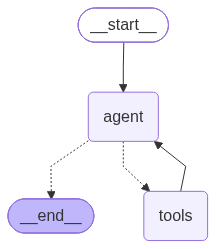

In [23]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

&emsp;&emsp;返回的是编译好的`LangGraph`可运行程序，可直接用于聊天交互。调用方式则和之前使用的方法一样，我们可以依次针对不同复杂程度的需求依次进行提问。首先是测试是否可以不使用工具，直接调用大模型生成响应。

In [24]:
# query="你好，请你介绍一下你自己"
# input_message = {"messages": [HumanMessage(content=query)]}

# 可以自动处理成 HumanMessage 的消息格式
finan_response = graph.invoke({"messages":["你好，请你介绍一下你自己"]})
finan_response

{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}, id='d59b1e98-5166-46f5-891c-71741c8556ff'),
  AIMessage(content='你好！我是你的AI助手，很高兴为你服务。\n\n我可以帮你完成很多事情，比如：\n\n1. **查询实时天气** — 我可以查询全球各大城市的当前天气情况，包括温度、湿度、风速、天气状况等信息。\n\n2. **获取实时信息** — 我可以联网搜索最新的互联网信息，回答你关于新闻、知识、数据等方面的问题。\n\n3. **管理天气数据** — 我还可以将查询到的天气信息存入数据库，或者从数据库中查询历史天气记录。\n\n4. **日常对话与解答** — 无论是生活问题、学习问题还是工作问题，我都可以尽力为你提供帮助。\n\n如果你有任何需要，随时告诉我！比如你想了解某个城市的天气，或者想查询某些实时信息，我都可以帮你处理。😊\n\n请问有什么我可以帮你的吗？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 164, 'prompt_tokens': 1061, 'total_tokens': 1225, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 1061}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '0086af46-a8f2-40d1-aea0-48a3ec283660', 'finish_reason

In [25]:
finan_response["messages"][-1].content

'你好！我是你的AI助手，很高兴为你服务。\n\n我可以帮你完成很多事情，比如：\n\n1. **查询实时天气** — 我可以查询全球各大城市的当前天气情况，包括温度、湿度、风速、天气状况等信息。\n\n2. **获取实时信息** — 我可以联网搜索最新的互联网信息，回答你关于新闻、知识、数据等方面的问题。\n\n3. **管理天气数据** — 我还可以将查询到的天气信息存入数据库，或者从数据库中查询历史天气记录。\n\n4. **日常对话与解答** — 无论是生活问题、学习问题还是工作问题，我都可以尽力为你提供帮助。\n\n如果你有任何需要，随时告诉我！比如你想了解某个城市的天气，或者想查询某些实时信息，我都可以帮你处理。😊\n\n请问有什么我可以帮你的吗？'

&emsp;&emsp;加大输入问题的复杂度，接下来我们提问的问题希望它能够自动找到正确的工具函数，基于工具的执行结果作为既定的事实，引导生成最终的回复。

In [27]:
finan_response = graph.invoke({"messages":["北京今天的天气怎么样？"]})

finan_response

{'messages': [HumanMessage(content='北京今天的天气怎么样？', additional_kwargs={}, response_metadata={}, id='bcb800c2-d887-4134-9ef7-98644fe5176c'),
  AIMessage(content='我来帮您查询北京今天的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 1061, 'total_tokens': 1114, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 37}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '75094389-5876-4a92-9be5-21450c5f34eb', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5c3-2cc6-7590-a2e3-2705da55a632-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Beijing'}, 'id': 'call_00_GImxvRgL1PqitfYbMULj4495', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1061, 'output_tokens': 53, 'total_tok

In [28]:
finan_response["messages"][-1].content

'我已经获取到北京今天的天气信息，让我为您整理一下：\n\n## ☀️ 北京今日天气\n\n**天气状况：** 晴天（Clear）\n\n| 项目 | 数值 |\n|------|------|\n| 🌡️ 当前温度 | **30.7°C** |\n| 🤔 体感温度 | 30.6°C |\n| 📊 最低/最高温 | 30.7°C / 30.7°C |\n| 💧 湿度 | 41% |\n| 🌬️ 风速 | 3.11 m/s（南风） |\n| 👁️ 能见度 | 10公里 |\n| ☁️ 云量 | 9% |\n| 🌀 气压 | 1007 hPa |\n\n**温馨提示：**\n- 今天北京天气晴朗，阳光充足，气温较高（约31°C），体感较热。\n- 湿度适中（41%），但天气炎热，建议外出时注意防晒、补水。\n- 能见度良好，适合户外活动。\n\n请问还需要了解其他信息吗？比如未来几天的天气预报，或者是否需要我将这些天气数据保存到数据库中？'

In [29]:
finan_response = graph.invoke({"messages":["北京今天的天气怎么样？"]})

finan_response

{'messages': [HumanMessage(content='北京今天的天气怎么样？', additional_kwargs={}, response_metadata={}, id='9fd76fe9-a45e-4afa-8968-54dff3b63bbd'),
  AIMessage(content='我来帮您查询北京今天的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 1061, 'total_tokens': 1114, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 37}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 'c1d5d9ac-41e7-4a81-8df0-2b86315ac8ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5c3-9346-7833-b9f4-69777ad751f3-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Beijing'}, 'id': 'call_00_kj1w6Ib8P96VXmciiSzO8970', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1061, 'output_tokens': 53, 'total_tok

In [30]:
finan_response = graph.invoke({"messages":["你知道关于小米的销售情况吗？请用中文回复我"]})

finan_response

{'messages': [HumanMessage(content='你知道关于小米的销售情况吗？请用中文回复我', additional_kwargs={}, response_metadata={}, id='5dbcb027-2ceb-46ba-ad66-2b2a82fe46a4'),
  AIMessage(content='我来帮你查询一下小米的销售情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 1069, 'total_tokens': 1133, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 45}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '24115f0c-e026-45d4-b5c1-9c3f6517c114', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5c3-a199-74d1-bc3b-a0ff0eef16e9-0', tool_calls=[{'name': 'fetch_real_time_info', 'args': {'query': '小米公司最新销售情况 2024 2025'}, 'id': 'call_00_4vCtvhXoKLv6NMnXyi4b3773', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1069, 'o

In [31]:
finan_response["messages"][-1].content

'根据我查询到的实时信息，下面为你整理小米的销售情况：\n\n## 小米销售情况汇总（截至2025年第三季度）\n\n### 📊 整体业绩\n- **2025年第三季度总收入**：人民币 **1,131亿元**，同比增长 **22.3%**\n- 其中「手机×AIoT」分部收入为人民币 **841亿元**\n\n### 📱 智能手机业务\n- **2025年第三季度智能手机出货量**：**4,330万台**，同比增长 **0.5%**\n- 根据Omdia数据，小米全球智能手机出货量**排名前三**，市场份额为 **13.6%**\n- 已**连续21个季度**排名全球前三\n\n### 🚗 智能电动汽车业务（重点亮点）\n- **2025年第三季度汽车交付量**：**108,796辆**\n- 相比第二季度的81,302辆，**环比增长33.8%**\n- 汽车交付量及平均售价（ASP）均有所增加，带动了相关收入增长\n\n### 🏠 AIoT生态\n- 小米AIoT平台已连接的IoT设备数量持续增长，生态规模不断扩大\n\n### 💰 费用支出\n- 销售及推广开支由2024年第三季度的63亿元增加32.3%至2025年第三季度的**83亿元**，主要是由于**小米之家及汽车销售门店扩张**相关开支增加\n\n---\n\n**总结**：小米目前处于**手机业务稳健**、**汽车业务高速增长**的发展阶段。手机保持全球前三的市场地位，而智能电动汽车业务（SU7等车型）成为新的增长引擎，交付量环比大幅提升，显示出强劲的市场需求。\n\n如果你对某个具体方面（比如汽车销量、手机市场份额、海外市场等）想了解更多，我可以进一步帮你查询！'

&emsp;&emsp;继续加大问题的难度，我们要在一个问题中涉及多个工具的使用，比如：

In [32]:
finan_response = graph.invoke({"messages":["帮我查一下北京、上海，哈尔滨三个城市的天气，告诉我哪个城市最适合出游。同时，把查询到的数据存储到数据库中"]})

finan_response

{'messages': [HumanMessage(content='帮我查一下北京、上海，哈尔滨三个城市的天气，告诉我哪个城市最适合出游。同时，把查询到的数据存储到数据库中', additional_kwargs={}, response_metadata={}, id='4c1ca289-c6ca-479a-a0ca-ec906e60cf61'),
  AIMessage(content='我来帮你查询北京、上海、哈尔滨三个城市的天气情况。首先，让我同时查询这三个城市的实时天气数据。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 1083, 'total_tokens': 1216, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 59}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '26f267ec-ef13-4e58-8ce8-82e1450fcb12', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5c4-37f8-7eb0-8030-d40a0dfaaa23-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Beijing'}, 'id': 'call_00_iU1AnyjrJfyLP336Pk997056', 'type': 'tool_call'}, {'name': 'get_weathe

In [33]:
finan_response["messages"][-1].content

'三个城市的天气数据都已成功存储到数据库中了。下面为你汇总查询结果：\n\n---\n\n## 🌤️ 三城市天气查询结果\n\n### 1️⃣ 北京（Beijing）\n- **天气状况**：☀️ 晴天\n- **温度**：30.7°C（体感 30.6°C）\n- **湿度**：41%\n- **风力**：3.11 m/s（东南风）\n- **能见度**：10 km\n- **气压**：1007 hPa\n\n### 2️⃣ 上海（Shanghai）\n- **天气状况**：🌧️ 中到大阵雨\n- **温度**：25.7°C（体感 25.1°C）\n- **湿度**：92%\n- **风力**：10.89 m/s（东北风，风力较大）\n- **能见度**：7 km\n- **气压**：995 hPa\n\n### 3️⃣ 哈尔滨（Harbin）\n- **天气状况**：☁️ 阴天\n- **温度**：24.6°C（体感 24.5°C）\n- **湿度**：47%\n- **风力**：1.39 m/s（微风）\n- **能见度**：10 km\n- **气压**：1011 hPa\n\n---\n\n## 🏆 最适合出游的城市：**北京**\n\n**推荐理由：**\n- ✅ **天气晴朗**，阳光充足，非常适合户外活动\n- ✅ **湿度适中**（41%），体感舒适\n- ✅ **能见度高**（10km），视野开阔\n- ✅ **风力较小**，出行方便\n\n相比之下：\n- ❌ **上海**正在下中到大阵雨，湿度高达92%，风力也较大，不适合出游\n- ⚠️ **哈尔滨**虽然是阴天但温度适宜，不过阴天天气不如晴天适合出游\n\n---\n\n✅ **数据存储情况**：北京、上海、哈尔滨三个城市的天气数据均已成功存储到 MySQL 数据库中。\n\n如果你需要进一步查询数据库中的历史数据，随时告诉我！'

&emsp;&emsp;同时，可以在数据库中查看数据的插入情况：

In [34]:
finan_response = graph.invoke({"messages":["帮我分析一下数据库中北京和哈尔滨城市天气的信息，做一个详细的对比，并生成出行建议"]})

finan_response

{'messages': [HumanMessage(content='帮我分析一下数据库中北京和哈尔滨城市天气的信息，做一个详细的对比，并生成出行建议', additional_kwargs={}, response_metadata={}, id='6973001e-1d0e-4652-93eb-c66d84349b3e'),
  AIMessage(content='我来帮你分析北京和哈尔滨的天气信息。首先，让我从数据库中查询这两个城市的天气数据。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 1075, 'total_tokens': 1177, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 51}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 'd591d929-06d7-46e3-b70b-45d3a69bb4f8', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5c5-0d76-74c3-8486-9dc0f062a004-0', tool_calls=[{'name': 'query_weather_from_db', 'args': {'city_name': '北京'}, 'id': 'call_00_GEqPqrNpIBHRdWqa0lxF5759', 'type': 'tool_call'}, {'name': 'query_weather_from_db'

In [35]:
print(finan_response["messages"][-1].content)

数据已成功存储并确认。现在我来为你做详细的对比分析和出行建议。

---

# 🌤️ 北京 vs 哈尔滨 天气详细对比分析

## 一、基础天气概况

| 对比项 | 🏙️ 北京 | ❄️ 哈尔滨 |
|--------|---------|----------|
| **天气状况** | ☀️ 晴天 | ☁️ 阴天 |
| **气温** | 30.7°C | 24.6°C |
| **体感温度** | 30.6°C | 24.5°C |
| **最高/最低温** | 30.7°C / 30.7°C | 24.6°C / 24.6°C |
| **气压** | 1007 hPa | 1011 hPa |
| **湿度** | 41% | 47% |
| **能见度** | 10 km | 10 km |
| **风速** | 3.11 m/s | 1.39 m/s |
| **风向** | 南风（172°） | 东南风（152°） |
| **云量** | 9%（晴空） | 94%（阴天） |

---

## 二、详细对比分析

### 🌡️ 温度对比
- **北京明显更热**：气温高达 **30.7°C**，属于炎热天气，体感温度也接近31°C。
- **哈尔滨相对凉爽**：气温 **24.6°C**，比北京低约 **6°C**，体感舒适。
- 两地温差较大，出行需注意衣物调整。

### ☁️ 天气状况对比
- **北京**：**晴天**，云量仅9%，阳光充足，适合户外活动，但紫外线较强。
- **哈尔滨**：**阴天**，云量高达94%，几乎完全被云层覆盖，阳光较弱，天气略显沉闷。

### 💧 湿度对比
- 两地湿度都在 **40%-50%** 之间，属于较为干燥舒适的范围。
- 哈尔滨（47%）略高于北京（41%），但差异不大。

### 🌬️ 风力对比
- **北京**：风速 **3.11 m/s**，风力稍大，有助于缓解炎热感。
- **哈尔滨**：风速 **1.39 m/s**，风力较小，天气较为平静。

### 📊 综合舒适度
- **北京**：炎热+晴天+微风 → 体感偏热，注意防晒防暑。
- **哈尔滨**：凉爽+阴天+微风 → 体感舒适，适合出行。

---

## 三、出行建议

### 🏙️ 前往北京的建议
1. **防晒防暑**：北京

根据数据库中的天气信息，这里有对北京和哈尔滨的天气对比及出行建议：

### 北京天气信息
- **天气状况**: 晴
- **气温**: 当前温度 2.94°C
- **体感温度**: -1.18°C
- **最低温度**: 2.94°C
- **最高温度**: 2.94°C

### 哈尔滨天气信息
- **天气状况**: 少云
- **气温**: 当前温度 -11.03°C
- **体感温度**: -16.88°C
- **最低温度**: -11.03°C
- **最高温度**: -11.03°C

### 天气对比
- **天气方面**: 北京是晴天，哈尔滨则是少云的天气。
- **温度方面**: 北京比哈尔滨温暖得多，体感温度上北京接近零度，而哈尔滨则感觉非常寒冷，接近零下十七度。

### 出行建议
1. **北京**:
   - 建议穿着保暖的衣物如厚外套加保暖内衣，以应对略低的体感温度。
   - 户外活动适宜，因为天气晴好，但切勿忽略防寒措施。

2. **哈尔滨**:
   - 建议穿戴多层厚衣物、围巾、手套、帽子等，以抵御刺骨的寒冷。
   - 室外活动尽量减少长时间停留，注意保暖。
   - 行车时注意路面可能的结冰，安全驾驶。

希望这些信息对您的出行计划有所帮助！

&emsp;&emsp;通过对不同复杂程度输入问题的测试，我们发现当前架构能够非常准确且快速地完成任务目标。在涉及多个任务的顺序执行时，`ReAct` 代理能够自主决策并执行，真正实现了完全的自治循环代理。此外，其可扩展性也十分出色。**对于不同的业务需求，我们只需调整接入的大模型实例（可使用其他开源或在线模型）作为 `ReAct` 的基础模型。对于工具的配置，也无需特别进行复杂的编排，只需明确定义每个工具的输入和输出，然后通过工具列表的形式直接注册到大模型实例及 `ToolNode` 实例中**。这种方法在快速构建智能代理方面，非常值得大家尝试。